In [1]:
import pandas as pd

from matplotlib import pyplot as plt

from pathlib import Path

In [44]:
DATA_DIR = Path(f"../../artifacts/2023-06-s8/distill-superclasses-wd")

In [45]:
def load_data(dataset, layer, n, compr, basis_name, basis_mode, model, weight_decay, seeds=[1, 2, 3, 4, 5]):
    
    data_dir = DATA_DIR / dataset / model
    
    arr_dfs = []
    
    
    
    
    for seed in seeds:
        slug =  f"layer{layer}-n{n}-wd{weight_decay}-comp{compr}-seed{seed}/{basis_name}--{basis_mode}"

        _df = pd.read_csv(data_dir / slug / "result.csv")
        _df["seed"] = seed
    
        arr_dfs.append(_df)
        
    return pd.concat(arr_dfs)

load_data(
    "cifar100-people",
    layer="layer3",
    n=50,
    compr=0.01,
    model="cifar100-resnet18-p1",
    basis_name="random1",
    basis_mode="centered",
    weight_decay=0.0
)

,layer,epoch,epoch_val_acc,epoch_train_acc,teacher_acc,student_acc_before_training,student_trainable_param,student_total_params,teacher_total_params,seed
0,layer3,0,0.200,0.200,0.55,0.186,2608,9123028,11220132,1
1,layer3,1,0.200,0.200,0.55,0.186,2608,9123028,11220132,1
2,layer3,2,0.202,0.200,0.55,0.186,2608,9123028,11220132,1
3,layer3,3,0.196,0.188,0.55,0.186,2608,9123028,11220132,1
4,layer3,4,0.208,0.208,0.55,0.186,2608,9123028,11220132,1
...,...,...,...,...,...,...,...,...,...,...
95,layer3,95,0.228,0.300,0.55,0.220,2608,9123028,11220132,5
96,layer3,96,0.236,0.308,0.55,0.220,2608,9123028,11220132,5
97,layer3,97,0.230,0.316,0.55,0.220,2608,9123028,11220132,5
98,layer3,98,0.232,0.332,0.55,0.220,2608,9123028,11220132,5


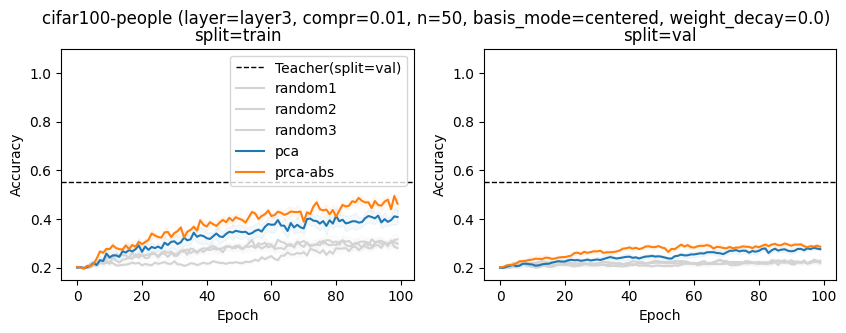

In [48]:
def get_color(name):
    if "random" in name:
        return "lightgray"
    else:
        return None
    
def viz(dataset, layer, n, compr, basis_mode, seeds=list(range(1, 5+1)), weight_decay=0.0, model="cifar100-resnet18-p1"):
    basis_names = [

        "random1", 
        "random2", 
        "random3",
        
        "pca",
        "prca-abs",
    ]
    
    ncols = 2
    
    plt.figure(figsize=(5*ncols, 3))
    plt.suptitle(
        f"{dataset} (layer={layer}, compr={compr}, n={n}, basis_mode={basis_mode}, weight_decay={weight_decay})",
        y=1.01
    )

    for cix, col in enumerate(["train", "val"]):
        plt.subplot(1, ncols, cix+1)
        plt.title(f"split={col}")
        for bix, basis_name in enumerate(basis_names):
            df = load_data(
                dataset=dataset,
                layer=layer,
                n=n,
                compr=compr,
                basis_name=basis_name,
                seeds=seeds,
                model=model,
                basis_mode=basis_mode,
                weight_decay=weight_decay
            )


            epochs = df[df.seed==1].epoch.values

            if bix == 0:
                teacher_auroc = df[df.seed==1].teacher_acc.values[-1]
                plt.axhline(teacher_auroc, ls="--", lw=1, color="k", label="Teacher(split=val)")

            mean = df.groupby(by="epoch")[f"epoch_{col}_acc"].mean()
            

            std = df.groupby(by="epoch")[f"epoch_{col}_acc"].std()
            count = df.groupby(by="epoch")[f"epoch_{col}_acc"].count()

            stderr = std / (count)**0.5

            plt.plot(
                epochs,
                mean,
                label=basis_name,
                color=get_color(basis_name)
            )

            color = plt.gca().lines[-1].get_color()
            plt.fill_between(
                epochs,
               mean - stderr,
               mean + stderr,
               alpha=0.05,
               color=color
            )

        if cix == 0:
            plt.legend()
        plt.ylim([0.15, 1.1])
        plt.ylabel("Accuracy")
        plt.xlabel("Epoch")

viz(dataset="cifar100-people", layer="layer3", n=50, compr=0.01, basis_mode="centered", weight_decay=0.0)

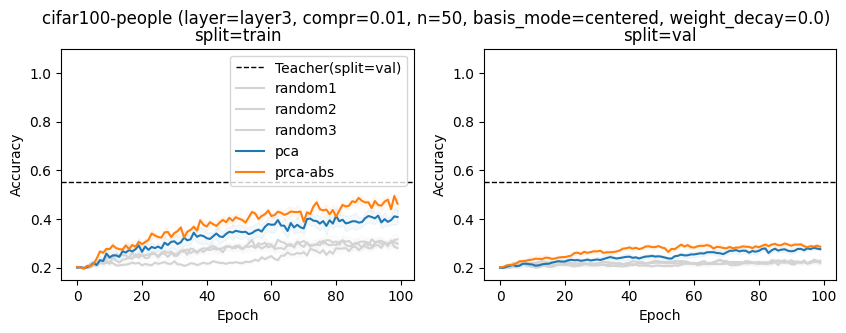

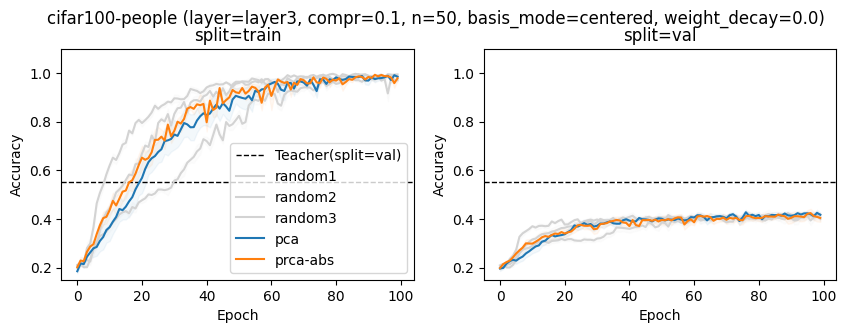

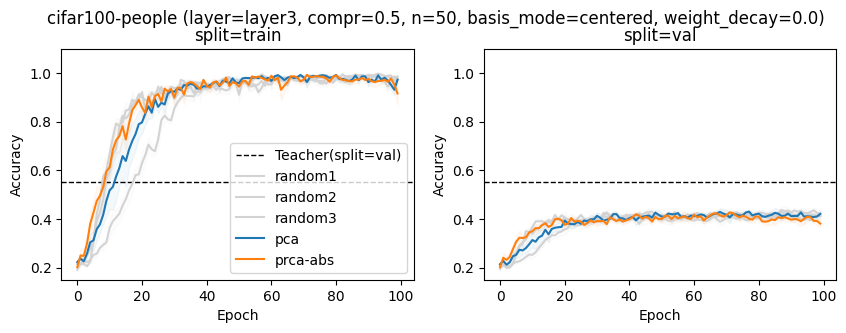

In [54]:
for c in [0.01, 0.1, 0.5]:
    viz(dataset="cifar100-people", layer="layer3", n=50, compr=c, basis_mode="centered", weight_decay=0.0)

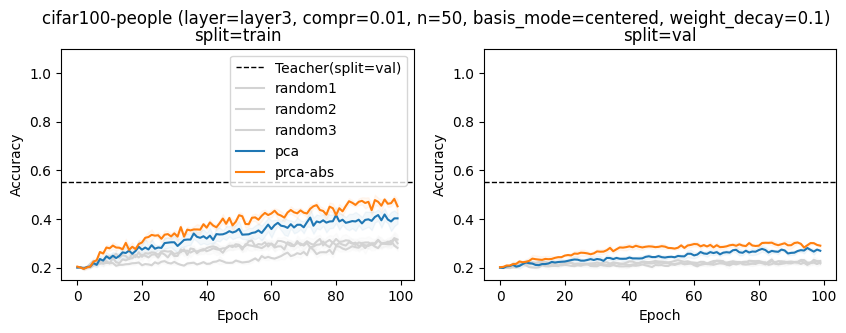

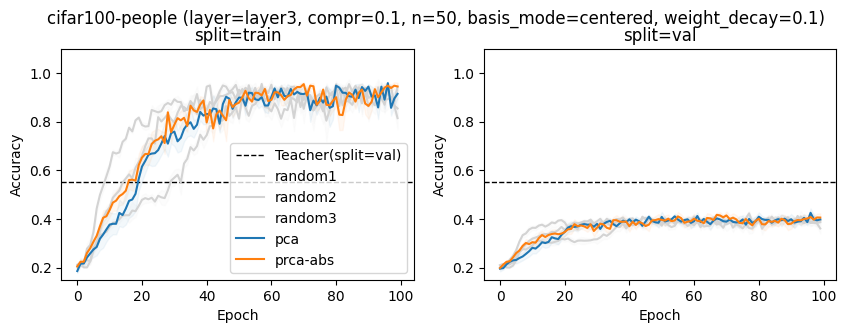

In [56]:
for c in [0.01, 0.1]:
    viz(dataset="cifar100-people", layer="layer3", n=50, compr=c, basis_mode="centered", weight_decay=0.1)

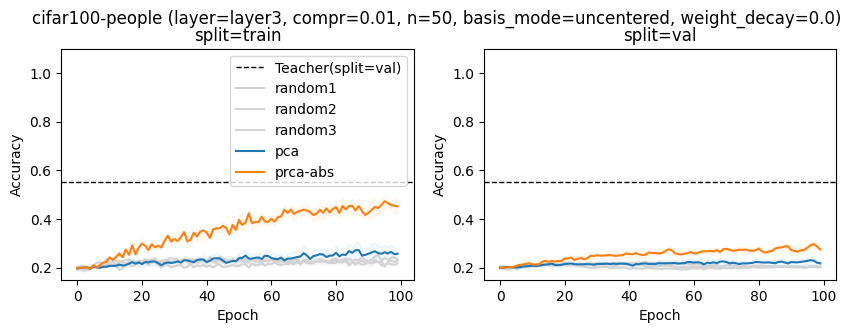

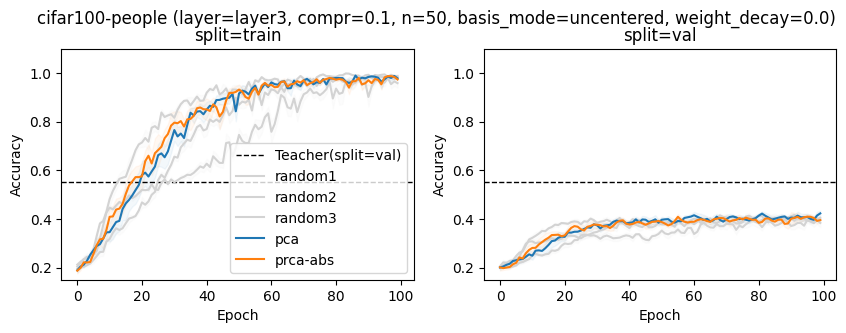

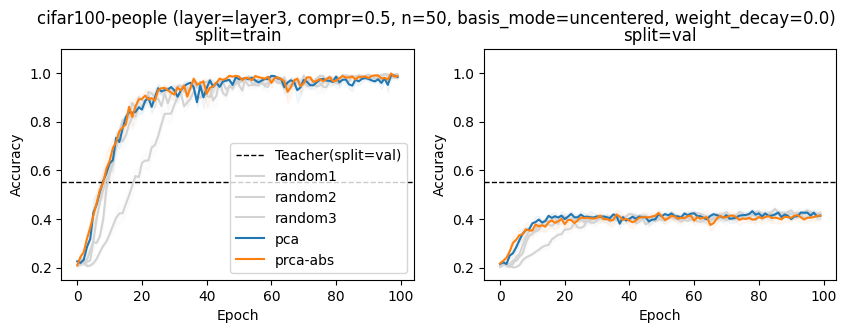

In [60]:
for c in [0.01, 0.1, 0.5]:
    viz(dataset="cifar100-people", layer="layer3", n=50, compr=c, basis_mode="uncentered", weight_decay=0.0)

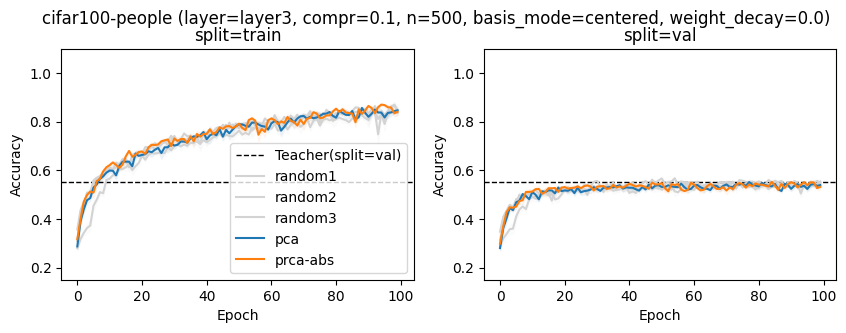

In [62]:
for c in [0.1]:
    viz(dataset="cifar100-people", layer="layer3", n=500, compr=c, basis_mode="centered", weight_decay=0.0)

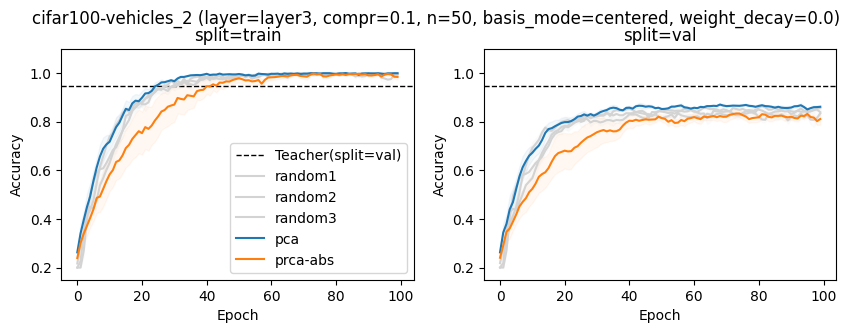

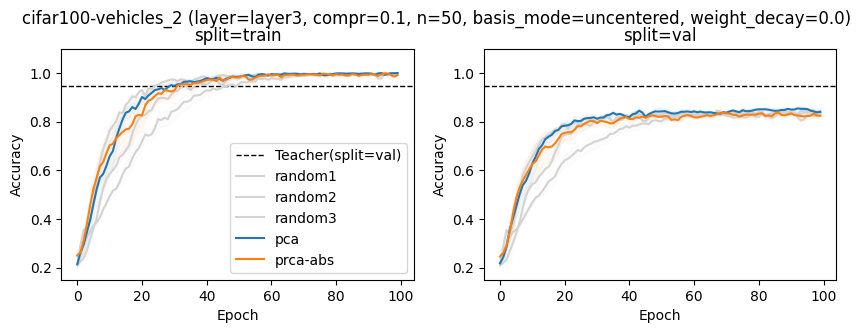

In [66]:
for c in ["centered", "uncentered"]:
    viz(dataset="cifar100-vehicles_2", layer="layer3", n=50, compr=0.1, basis_mode=c, weight_decay=0.0)